# QPA Fidelity Decay — Unrolled Strategy (Small) — IBM Pittsburgh

Lightweight version of `end_to_end_unrolled_pittsburgh.ipynb` designed to finish quickly.

**Differences from the full notebook:**
- `N_RANDOM = 1000` Pauli twirling instances per λ
- `SHOTS = 10` shots per circuit instance
- λ sweep is **split into two passes** (`LAMBDA_PHASE`):
  - `"even"` → `0.0, 0.2, 0.4, 0.6, 0.8`
  - `"odd"`  → `0.1, 0.3, 0.5, 0.7, 0.9`
  - `"all"`  → `0.0, 0.1, …, 0.9`
- `N ∈ {3, 5, 7}`, `K = 2`, `T = 1`
- Multi-seed transpilation (10 seeds), keep the circuit with the lowest 2Q depth per path
- Results are checkpointed to CSV + JSON after **every** λ point so the run can be resumed if interrupted

**Two-pass workflow.** Run once with `LAMBDA_PHASE = "even"`, then change it to `"odd"` and re-run the same notebook. The checkpoint files accumulate across phases — every cell automatically loads prior λ points from the CSV and only computes the missing ones, so the final plot/consolidation will show the full `0.0, 0.1, …, 0.9` set.

Pipeline:
1. Configuration
2. Backend setup (`ibm_pittsburgh`)
3. Circuit generation (unrolled)
4. Transpilation — 10 seeds, pick lowest 2Q depth
5. Noise application (Pauli twirling)
6. Submission to IBM, with per-λ checkpointing
7. Plot vs. theory
8. Consolidated final save

In [14]:
import json
import os
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from qiskit import transpile
from qiskit.circuit import CircuitInstruction
from qiskit.circuit.library import XGate, RZGate
from qiskit_ibm_runtime import SamplerV2 as IBMSampler

from core.circuit_factory import CircuitFactory
from core.noise_models import PauliTwirlingStrategy
from execution.backend_handler import IBMRuntimeHandler
from analysis.result_processor import ResultProcessor

print("Imports loaded.")

Imports loaded.


## Step 1: Configuration

| Parameter | Value |
|-----------|-------|
| `N` | 3, 5, 7 |
| `K` | 2 |
| `T` | 1 |
| `LAMBDA_PHASE` | `"even"` / `"odd"` / `"all"` |
| λ values | union of `{0.0, 0.2, 0.4, 0.6, 0.8}` and `{0.1, 0.3, 0.5, 0.7, 0.9}` across passes |
| `N_RANDOM` | 1000 |
| `SHOTS` | 10 |
| `TRANSPILE_SEEDS` | 10 (lowest 2Q depth wins) |
| `DEVICE` | `ibm_pittsburgh` |

In [ ]:
# ----- Experiment Parameters -----
K = 2                        # Qubits per register (d = 2^K = 4)
T = 1                        # Number of QPA trial rounds
N_RANDOM = 5000              # Pauli twirling instances per λ * 4 or 5
SHOTS = 3                   # Shots per circuit instance
BATCH_SIZE = 300             # Circuits per IBM job submission
TRANSPILE_SEEDS = 10         # Multi-seed transpilation, pick lowest 2Q depth
OPT_LEVEL = 3                # Transpiler optimization level
DEVICE = "ibm_pittsburgh"
NO_RESET = False

# ----- Lambda phase selector -----
# Pick which λ values to run *this pass*. The checkpoint/resume logic merges
# results across passes, so running "even" then "odd" gives the full set
# {0.0, 0.1, …, 0.9} in the consolidated CSV/JSON without recomputing.
#   "even" -> [0.0, 0.2, 0.4, 0.6, 0.8]
#   "odd"  -> [0.1, 0.3, 0.5, 0.7, 0.9]
#   "all"  -> [0.0, 0.1, …, 0.9]   (still skips any λ already in checkpoint)
LAMBDA_PHASE = "odd"

LAMBDA_SETS = {
    "even": np.round(np.array([0.0, 0.2, 0.4, 0.6, 0.8]), 4),
    "odd":  np.round(np.array([0.1, 0.3, 0.5, 0.7, 0.9]), 4),
    "all":  np.round(np.arange(0.0, 1.0, 0.1), 4),
}
if LAMBDA_PHASE not in LAMBDA_SETS:
    raise ValueError(f"LAMBDA_PHASE must be one of {list(LAMBDA_SETS)}, got {LAMBDA_PHASE!r}")
lambdas = LAMBDA_SETS[LAMBDA_PHASE]

EXPERIMENTS = [
    {"n": 3, "k": K, "t": T, "label": "N=3, K=2, T=1"},
    {"n": 5, "k": K, "t": T, "label": "N=5, K=2, T=1"},
    {"n": 7, "k": K, "t": T, "label": "N=7, K=2, T=1"},
]

# Output directory for incremental checkpoints
RESULTS_DIR = os.path.join("data", "results", "end_to_end_unrolled_small")
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"LAMBDA_PHASE = {LAMBDA_PHASE!r}")
print(f"Lambda sweep this pass ({len(lambdas)} points): {lambdas.tolist()}")
print(f"N_RANDOM={N_RANDOM}, SHOTS={SHOTS}, BATCH_SIZE={BATCH_SIZE}")
print(f"Transpile seeds per path: {TRANSPILE_SEEDS}")
print(f"Experiments: {[e['label'] for e in EXPERIMENTS]}")
print(f"Results directory: {RESULTS_DIR}")

LAMBDA_PHASE = 'odd'
Lambda sweep this pass (5 points): [0.1, 0.3, 0.5, 0.7, 0.9]
N_RANDOM=1000, SHOTS=10, BATCH_SIZE=300
Transpile seeds per path: 10
Experiments: ['N=3, K=2, T=1', 'N=5, K=2, T=1', 'N=7, K=2, T=1']
Results directory: data/results/end_to_end_unrolled_small


## Step 2: Backend Setup

In [16]:
backend_handler = IBMRuntimeHandler(backend_name=DEVICE)
backend = backend_handler.get_backend()

print(f"Backend: {backend.name}")
print(f"Number of qubits: {backend.num_qubits}")
print(f"Backend status: {backend.status()}")

qiskit_runtime_service._discover_account:WARNING:2026-05-01 10:42:48,575: Loading account with the given token. A saved account will not be used.


Connecting to IBM Runtime Service via channel='ibm_cloud'...
Backend: ibm_pittsburgh
Number of qubits: 156
Backend status: <qiskit_ibm_runtime.models.backend_status.BackendStatus object at 0x1192c3d90>


## Step 3: Circuit Generation (Unrolled Strategy)

- N=3 (1 pair / trial): 2 paths
- N=5 (2 pairs / trial): 4 paths
- N=7 (3 pairs / trial): 8 paths

In [17]:
golden_data_per_exp = {}

for exp in EXPERIMENTS:
    n = exp["n"]
    label = exp["label"]

    strategy = CircuitFactory.create_strategy("unrolled", K, T, n, no_reset=NO_RESET)
    strategy.set_noise_strategy(None)
    golden_data = strategy.build(0.0)

    golden_circuits = [item['circuit'] for item in golden_data]
    golden_metadata = [{k: v for k, v in item.items() if k != 'circuit'} for item in golden_data]

    golden_data_per_exp[n] = {
        'circuits': golden_circuits,
        'metadata': golden_metadata,
        'strategy': strategy,
    }

    print(f"\n--- {label} ---")
    print(f"  Total unrolled paths: {len(golden_circuits)}")
    print(f"  Qubits/circuit: {golden_circuits[0].num_qubits}, Clbits/circuit: {golden_circuits[0].num_clbits}")


--- N=3, K=2, T=1 ---
  Total unrolled paths: 2
  Qubits/circuit: 7, Clbits/circuit: 3

--- N=5, K=2, T=1 ---
  Total unrolled paths: 4
  Qubits/circuit: 12, Clbits/circuit: 4

--- N=7, K=2, T=1 ---
  Total unrolled paths: 8
  Qubits/circuit: 17, Clbits/circuit: 5


## Step 4: Multi-Seed Transpilation

For each golden circuit (path), transpile with `TRANSPILE_SEEDS` different `seed_transpiler` values at `optimization_level=3`. Keep the circuit with the **lowest 2Q depth**. Ties broken by lower 2Q gate count.

In [18]:
def count_2q_gates(qc):
    return sum(1 for instr in qc.data if len(instr.qubits) == 2)

def transpile_best_of(qc, backend, n_seeds, opt_level):
    """Run n_seeds transpilations of qc; keep the one with lowest 2Q depth (tiebreak: 2Q gate count)."""
    best = None
    seed_stats = []
    for seed in range(n_seeds):
        qc_tr = transpile(qc, backend=backend, optimization_level=opt_level, seed_transpiler=seed)
        d2q = qc_tr.depth(lambda instr: len(instr.qubits) == 2)
        g2q = count_2q_gates(qc_tr)
        seed_stats.append((seed, d2q, g2q))
        if (best is None) or (d2q < best['d2q']) or (d2q == best['d2q'] and g2q < best['g2q']):
            best = {'seed': seed, 'd2q': d2q, 'g2q': g2q, 'circuit': qc_tr}
    return best, seed_stats

transpiled_per_exp = {}
transpile_summary_per_exp = {}

for exp in EXPERIMENTS:
    n = exp["n"]
    label = exp["label"]
    golden_circuits = golden_data_per_exp[n]['circuits']
    golden_metadata = golden_data_per_exp[n]['metadata']

    print(f"\nTranspiling {len(golden_circuits)} circuits for {label} ({TRANSPILE_SEEDS} seeds each)...")
    transpiled = []
    summary = []
    for i, qc in enumerate(tqdm(golden_circuits, desc=f"N={n}", leave=False)):
        best, seed_stats = transpile_best_of(qc, backend, TRANSPILE_SEEDS, OPT_LEVEL)
        transpiled.append(best['circuit'])

        path_name = golden_metadata[i].get('metadata', {}).get('path_name', f'path_{i}')
        ops = dict(best['circuit'].count_ops())
        summary.append({
            'path_name': path_name,
            'best_seed': best['seed'],
            'best_2q_depth': best['d2q'],
            'best_2q_gates': best['g2q'],
            'depth': best['circuit'].depth(),
            'all_seed_2q_depths': [s[1] for s in seed_stats],
        })
        print(f"  {path_name}: best seed={best['seed']}, 2Q depth={best['d2q']}, 2Q gates={best['g2q']}, gates={ops}")

    transpiled_per_exp[n] = transpiled
    transpile_summary_per_exp[n] = summary

# Persist the transpilation summary (so we know which seeds were chosen)
summary_path = os.path.join(RESULTS_DIR, "transpile_summary.json")
with open(summary_path, 'w') as f:
    json.dump({str(n): transpile_summary_per_exp[n] for n in transpile_summary_per_exp}, f, indent=2)
print(f"\nTranspilation summary saved to: {summary_path}")


Transpiling 2 circuits for N=3, K=2, T=1 (10 seeds each)...


N=3:   0%|          | 0/2 [00:00<?, ?it/s]

  path_0: best seed=0, 2Q depth=18, 2Q gates=20, gates={'sx': 36, 'rz': 27, 'cz': 20, 'measure': 3, 'reset': 1}
  path_1: best seed=0, 2Q depth=18, 2Q gates=20, gates={'sx': 36, 'rz': 27, 'cz': 20, 'measure': 3, 'reset': 1}

Transpiling 4 circuits for N=5, K=2, T=1 (10 seeds each)...


N=5:   0%|          | 0/4 [00:00<?, ?it/s]

  path_0: best seed=0, 2Q depth=18, 2Q gates=40, gates={'sx': 72, 'rz': 54, 'cz': 40, 'measure': 4, 'reset': 2}
  path_1: best seed=0, 2Q depth=18, 2Q gates=40, gates={'sx': 72, 'rz': 54, 'cz': 40, 'measure': 4, 'reset': 2}
  path_2: best seed=0, 2Q depth=18, 2Q gates=40, gates={'sx': 72, 'rz': 54, 'cz': 40, 'measure': 4, 'reset': 2}
  path_3: best seed=0, 2Q depth=18, 2Q gates=40, gates={'sx': 72, 'rz': 54, 'cz': 40, 'measure': 4, 'x': 3, 'reset': 2}

Transpiling 8 circuits for N=7, K=2, T=1 (10 seeds each)...


N=7:   0%|          | 0/8 [00:00<?, ?it/s]

  path_0: best seed=0, 2Q depth=18, 2Q gates=60, gates={'sx': 108, 'rz': 81, 'cz': 60, 'measure': 5, 'reset': 3}
  path_1: best seed=0, 2Q depth=18, 2Q gates=60, gates={'sx': 108, 'rz': 81, 'cz': 60, 'measure': 5, 'reset': 3}
  path_2: best seed=0, 2Q depth=18, 2Q gates=60, gates={'sx': 108, 'rz': 81, 'cz': 60, 'measure': 5, 'reset': 3}
  path_3: best seed=0, 2Q depth=18, 2Q gates=60, gates={'sx': 108, 'rz': 81, 'cz': 60, 'measure': 5, 'reset': 3}
  path_4: best seed=0, 2Q depth=18, 2Q gates=60, gates={'sx': 108, 'rz': 81, 'cz': 60, 'measure': 5, 'reset': 3}
  path_5: best seed=0, 2Q depth=18, 2Q gates=60, gates={'sx': 108, 'rz': 81, 'cz': 60, 'measure': 5, 'reset': 3}
  path_6: best seed=0, 2Q depth=18, 2Q gates=60, gates={'sx': 108, 'rz': 81, 'cz': 60, 'measure': 5, 'reset': 3}
  path_7: best seed=0, 2Q depth=18, 2Q gates=60, gates={'sx': 108, 'rz': 81, 'cz': 60, 'measure': 5, 'x': 3, 'reset': 3}

Transpilation summary saved to: data/results/end_to_end_unrolled_small/transpile_summar

## Step 5: Noise Application & Circuit Instance Generation

Identical fast-path twirling as the full notebook: copy the transpiled circuit, sample Pauli noise, and inject ISA-safe gates at the front.

In [19]:
def build_noisy_batch(transpiled_golden, golden_circuits, golden_metadata, epsilon, n_random, batch_size):
    """Build batches of noisy circuit instances from pre-transpiled golden circuits."""
    all_batches = []
    batch_circuits = []
    batch_metadata = []

    for _ in range(n_random):
        noise_strategy = PauliTwirlingStrategy(K)

        for i, qc_transpiled in enumerate(transpiled_golden):
            qc_instance = qc_transpiled.copy()
            orig_qc = golden_circuits[i]

            data_regs = [reg for reg in orig_qc.qregs if reg.name.startswith("R")]
            noise_ops = noise_strategy.generate_noise_ops(data_regs, epsilon)

            layout = qc_transpiled.layout.initial_layout if qc_transpiled.layout else None

            for gate, logical_qubit in noise_ops:
                target_qubit = None
                if layout and logical_qubit in layout:
                    phys_qubit_idx = layout[logical_qubit]
                    target_qubit = qc_instance.qubits[phys_qubit_idx]
                elif logical_qubit in qc_instance.qubits:
                    target_qubit = logical_qubit
                else:
                    for q in qc_instance.qubits:
                        if hasattr(q, 'register') and hasattr(logical_qubit, 'register'):
                            if q.register.name == logical_qubit.register.name and q.index == logical_qubit.index:
                                target_qubit = q
                                break

                if target_qubit:
                    if gate.name == 'z':
                        qc_instance.data.insert(0, CircuitInstruction(RZGate(np.pi), (target_qubit,), ()))
                    elif gate.name == 'y':
                        qc_instance.data.insert(0, CircuitInstruction(RZGate(np.pi), (target_qubit,), ()))
                        qc_instance.data.insert(0, CircuitInstruction(XGate(), (target_qubit,), ()))
                    else:
                        qc_instance.data.insert(0, CircuitInstruction(gate, (target_qubit,), ()))

            batch_circuits.append(qc_instance)
            batch_metadata.append(golden_metadata[i])

            if len(batch_circuits) >= batch_size:
                all_batches.append((batch_circuits, batch_metadata))
                batch_circuits = []
                batch_metadata = []

    if batch_circuits:
        all_batches.append((batch_circuits, batch_metadata))

    return all_batches

print("build_noisy_batch() defined.")

build_noisy_batch() defined.


## Step 6: Submission with Incremental Checkpointing

After **every λ data point**, the partial result list is written to both `results_n{N}_k{K}_t{T}_unrolled_ibm_pittsburgh_small.csv` and the matching `.json`. If the kernel dies or the run is interrupted, re-running the cell will skip λs that already exist in the CSV and pick up where it left off.

In [20]:
def checkpoint_paths(n):
    base = f"results_n{n}_k{K}_t{T}_unrolled_ibm_pittsburgh_small"
    return (
        os.path.join(RESULTS_DIR, base + ".csv"),
        os.path.join(RESULTS_DIR, base + ".json"),
    )

def load_checkpoint(n):
    csv_path, _ = checkpoint_paths(n)
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        return df.to_dict('records')
    return []

def save_checkpoint(n, results, meta):
    csv_path, json_path = checkpoint_paths(n)
    df = pd.DataFrame(results)
    df.to_csv(csv_path, index=False)
    with open(json_path, 'w') as f:
        json.dump({'meta': meta, 'results': results}, f, indent=2)

def run_experiment(n, transpiled_golden, golden_circuits, golden_metadata,
                   lambdas, n_random, shots_per_circuit, batch_size, backend):
    """λ sweep for one N. Resumes from CSV checkpoint if it exists."""
    result_processor = ResultProcessor(K)
    sampler = IBMSampler(mode=backend)

    results = load_checkpoint(n)
    done_lambdas = {round(float(r['lambda']), 4) for r in results}
    if done_lambdas:
        print(f"  Resuming N={n}: {len(done_lambdas)} λ point(s) already in checkpoint -> {sorted(done_lambdas)}")

    meta = {
        'n': n, 'k': K, 't': T,
        'n_random': n_random, 'shots_per_circuit': shots_per_circuit,
        'batch_size': batch_size, 'backend': backend.name,
        'transpile_seeds': TRANSPILE_SEEDS, 'opt_level': OPT_LEVEL,
    }

    for epsilon in tqdm(lambdas, desc=f"N={n} λ sweep"):
        eps_key = round(float(epsilon), 4)
        if eps_key in done_lambdas:
            continue

        batches = build_noisy_batch(
            transpiled_golden, golden_circuits, golden_metadata,
            epsilon, n_random, batch_size,
        )

        global_path_stats = defaultdict(lambda: {'success': 0, 'total': 0})

        for batch_idx, (batch_circs, batch_meta) in enumerate(batches):
            pubs = [(qc, None, shots_per_circuit) for qc in batch_circs]
            try:
                job = sampler.run(pubs)
                pub_result = job.result()

                extracted_counts = ResultProcessor.extract_counts_from_job_result(pub_result, is_dynamic=False)

                total_clbits_list = []
                for counts in extracted_counts:
                    if counts:
                        first_key = next(iter(counts))
                        total_clbits_list.append(len(first_key.replace(" ", "")))
                    else:
                        total_clbits_list.append(0)

                batch_stats = result_processor.aggregate_batch_stats(
                    extracted_counts, batch_meta, total_clbits_list
                )
                for cond_key, stats in batch_stats.items():
                    global_path_stats[cond_key]['success'] += stats['success']
                    global_path_stats[cond_key]['total'] += stats['total']

            except Exception as e:
                print(f"  Error at λ={epsilon:.4f}, batch {batch_idx}: {e}")
                import traceback
                traceback.print_exc()

        fidelity = 0.0
        for stats in global_path_stats.values():
            if stats['total'] > 0:
                fidelity += stats['success'] / stats['total']

        results.append({'lambda': float(epsilon), 'fidelity': float(fidelity)})
        results.sort(key=lambda r: r['lambda'])
        save_checkpoint(n, results, meta)
        done_lambdas.add(eps_key)
        print(f"  N={n}, λ={epsilon:.4f} -> fidelity={fidelity:.4f}  [checkpoint saved]")

    return results

print("run_experiment() defined.")

run_experiment() defined.


### Run Experiment: N=3, K=2, T=1

In [21]:
results_n3 = run_experiment(
    n=3,
    transpiled_golden=transpiled_per_exp[3],
    golden_circuits=golden_data_per_exp[3]['circuits'],
    golden_metadata=golden_data_per_exp[3]['metadata'],
    lambdas=lambdas,
    n_random=N_RANDOM,
    shots_per_circuit=SHOTS,
    batch_size=BATCH_SIZE,
    backend=backend,
)
df_n3 = pd.DataFrame(results_n3)
print(f"\nN=3: {len(df_n3)} λ points collected")
df_n3

  Resuming N=3: 5 λ point(s) already in checkpoint -> [0.0, 0.2, 0.4, 0.6, 0.8]


N=3 λ sweep:   0%|          | 0/5 [00:00<?, ?it/s]

  N=3, λ=0.1000 -> fidelity=0.9727  [checkpoint saved]
  N=3, λ=0.3000 -> fidelity=0.9016  [checkpoint saved]
  N=3, λ=0.5000 -> fidelity=0.6851  [checkpoint saved]
  N=3, λ=0.7000 -> fidelity=0.5238  [checkpoint saved]
  N=3, λ=0.9000 -> fidelity=0.3594  [checkpoint saved]

N=3: 10 λ points collected


,lambda,fidelity
0,0.0,1.0247
1,0.1,0.9727
2,0.2,0.9011
3,0.3,0.9016
4,0.4,0.7743
5,0.5,0.6851
6,0.6,0.6078
7,0.7,0.5238
8,0.8,0.4321
9,0.9,0.3594


### Run Experiment: N=5, K=2, T=1

In [22]:
results_n5 = run_experiment(
    n=5,
    transpiled_golden=transpiled_per_exp[5],
    golden_circuits=golden_data_per_exp[5]['circuits'],
    golden_metadata=golden_data_per_exp[5]['metadata'],
    lambdas=lambdas,
    n_random=N_RANDOM,
    shots_per_circuit=SHOTS,
    batch_size=BATCH_SIZE,
    backend=backend,
)
df_n5 = pd.DataFrame(results_n5)
print(f"\nN=5: {len(df_n5)} λ points collected")
df_n5

  Resuming N=5: 5 λ point(s) already in checkpoint -> [0.0, 0.2, 0.4, 0.6, 0.8]


N=5 λ sweep:   0%|          | 0/5 [00:00<?, ?it/s]

  N=5, λ=0.1000 -> fidelity=0.9203  [checkpoint saved]
  N=5, λ=0.3000 -> fidelity=0.8228  [checkpoint saved]
  N=5, λ=0.5000 -> fidelity=0.6833  [checkpoint saved]
  N=5, λ=0.7000 -> fidelity=0.5015  [checkpoint saved]
  N=5, λ=0.9000 -> fidelity=0.3302  [checkpoint saved]

N=5: 10 λ points collected


,lambda,fidelity
0,0.0,0.9780
1,0.1,0.9203
2,0.2,0.8900
3,0.3,0.8228
4,0.4,0.7870
5,0.5,0.6833
6,0.6,0.6138
7,0.7,0.5015
8,0.8,0.4516
9,0.9,0.3302


### Run Experiment: N=7, K=2, T=1

In [23]:
results_n7 = run_experiment(
    n=7,
    transpiled_golden=transpiled_per_exp[7],
    golden_circuits=golden_data_per_exp[7]['circuits'],
    golden_metadata=golden_data_per_exp[7]['metadata'],
    lambdas=lambdas,
    n_random=N_RANDOM,
    shots_per_circuit=SHOTS,
    batch_size=BATCH_SIZE,
    backend=backend,
)
df_n7 = pd.DataFrame(results_n7)
print(f"\nN=7: {len(df_n7)} λ points collected")
df_n7

  Resuming N=7: 5 λ point(s) already in checkpoint -> [0.0, 0.2, 0.4, 0.6, 0.8]


N=7 λ sweep:   0%|          | 0/5 [00:00<?, ?it/s]

  N=7, λ=0.1000 -> fidelity=0.9181  [checkpoint saved]
  N=7, λ=0.3000 -> fidelity=0.8294  [checkpoint saved]
  N=7, λ=0.5000 -> fidelity=0.6877  [checkpoint saved]
  N=7, λ=0.7000 -> fidelity=0.5397  [checkpoint saved]
  N=7, λ=0.9000 -> fidelity=0.3636  [checkpoint saved]

N=7: 10 λ points collected


,lambda,fidelity
0,0.0,1.0968
1,0.1,0.9181
2,0.2,0.9714
3,0.3,0.8294
4,0.4,0.8226
5,0.5,0.6877
6,0.6,0.6464
7,0.7,0.5397
8,0.8,0.4308
9,0.9,0.3636


## Step 7: Plot — Experimental vs. Theory

Theory curves for K=2 (d=4):
- N=3: $F(\lambda) = \tfrac{1}{8}(8 - 2\lambda - 7\lambda^2 + 3\lambda^3)$
- N=5: $F(\lambda) = \tfrac{1}{640}(640 - 96\lambda - 224\lambda^2 - 700\lambda^3 + 693\lambda^4 - 153\lambda^5)$
- N=7: $F(\lambda) = \tfrac{1}{215040}(215040 - 23040\lambda - 50688\lambda^2 - 88768\lambda^3 - 311056\lambda^4 + 497192\lambda^5 - 207951\lambda^6 + 23031\lambda^7)$

Plot saved to: data/results/end_to_end_unrolled_small/fidelity_decay_unrolled_t1_ibm_pittsburgh_small.png


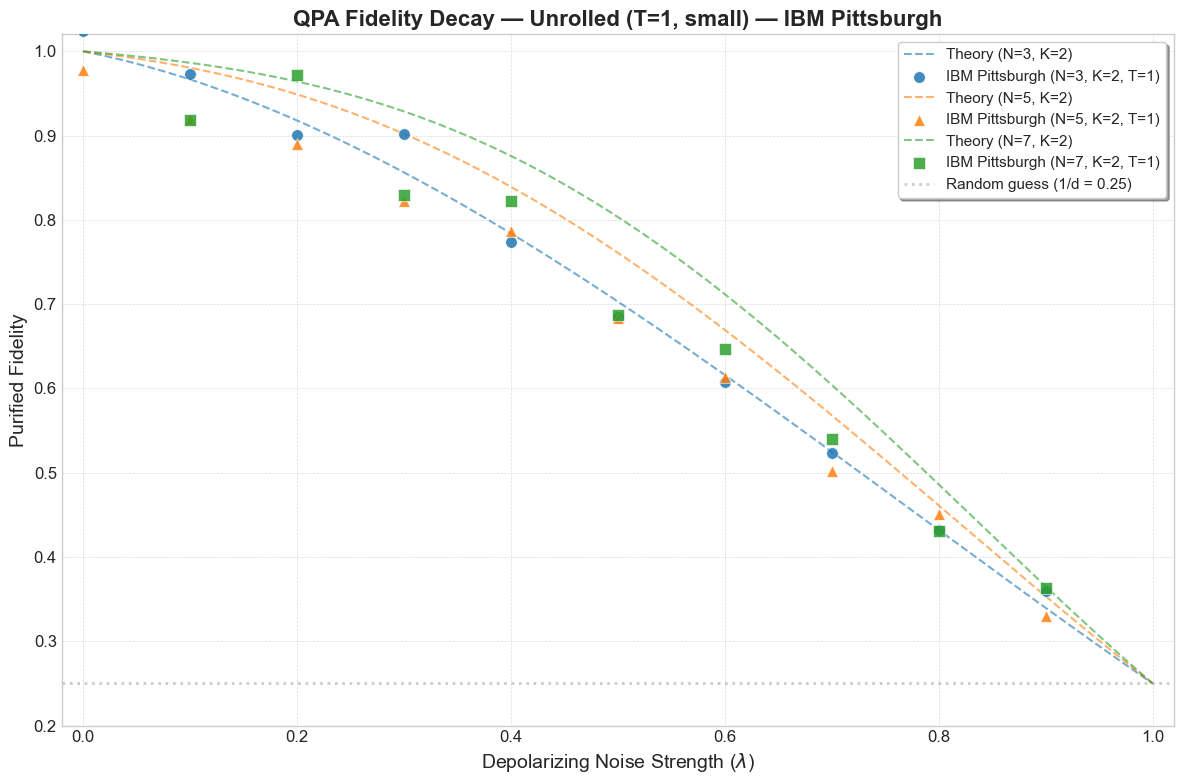

In [24]:
def theory_curve(lam, n, k):
    if k == 2:
        if n == 3:
            return (1/8) * (8 - 2*lam - 7*lam**2 + 3*lam**3)
        elif n == 5:
            return (1/640) * (640 - 96*lam - 224*lam**2 - 700*lam**3 + 693*lam**4 - 153*lam**5)
        elif n == 7:
            return (1/215040) * (215040 - 23040*lam - 50688*lam**2 - 88768*lam**3
                                  - 311056*lam**4 + 497192*lam**5 - 207951*lam**6 + 23031*lam**7)
    return None

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11,
    'lines.linewidth': 2, 'lines.markersize': 8,
})

fig, ax = plt.subplots(figsize=(12, 8))
lam_fine = np.linspace(0, 1, 200)
colors = {3: '#1f77b4', 5: '#ff7f0e', 7: '#2ca02c'}
markers = {3: 'o', 5: '^', 7: 's'}

for n, df in [(3, df_n3), (5, df_n5), (7, df_n7)]:
    th = theory_curve(lam_fine, n, K)
    ax.plot(lam_fine, th, '--', color=colors[n], linewidth=1.5, alpha=0.6,
            label=f'Theory (N={n}, K=2)')
    if len(df) > 0:
        ax.scatter(df['lambda'], df['fidelity'], color=colors[n], marker=markers[n], s=70,
                   zorder=5, alpha=0.85, edgecolors='white', linewidth=0.5,
                   label=f'IBM Pittsburgh (N={n}, K=2, T=1)')

ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.4, label='Random guess (1/d = 0.25)')
ax.set_title('QPA Fidelity Decay — Unrolled (T=1, small) — IBM Pittsburgh', fontweight='bold')
ax.set_xlabel(r'Depolarizing Noise Strength ($\lambda$)')
ax.set_ylabel('Purified Fidelity')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.20, 1.02)
ax.legend(loc='best', frameon=True, shadow=True)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, "fidelity_decay_unrolled_t1_ibm_pittsburgh_small.png")
plt.savefig(plot_path, dpi=300)
print(f"Plot saved to: {plot_path}")
plt.show()

## Step 8: Result Inspection

In [25]:
for n, df in [(3, df_n3), (5, df_n5), (7, df_n7)]:
    print(f"\n=== N={n}, K=2, T=1 ===")
    print(f"{'Lambda':>8} {'Exp Fidelity':>14} {'Theory':>10} {'Delta':>10}")
    print("-" * 46)
    for _, row in df.iterrows():
        lam = row['lambda']
        exp_f = row['fidelity']
        th_f = theory_curve(lam, n, K)
        delta = exp_f - th_f if th_f is not None else float('nan')
        print(f"{lam:8.4f} {exp_f:14.4f} {th_f:10.4f} {delta:+10.4f}")


=== N=3, K=2, T=1 ===
  Lambda   Exp Fidelity     Theory      Delta
----------------------------------------------
  0.0000         1.0247     1.0000    +0.0247
  0.1000         0.9727     0.9666    +0.0061
  0.2000         0.9011     0.9180    -0.0169
  0.3000         0.9016     0.8564    +0.0452
  0.4000         0.7743     0.7840    -0.0097
  0.5000         0.6851     0.7031    -0.0180
  0.6000         0.6078     0.6160    -0.0082
  0.7000         0.5238     0.5249    -0.0011
  0.8000         0.4321     0.4320    +0.0001
  0.9000         0.3594     0.3396    +0.0198

=== N=5, K=2, T=1 ===
  Lambda   Exp Fidelity     Theory      Delta
----------------------------------------------
  0.0000         0.9780     1.0000    -0.0220
  0.1000         0.9203     0.9805    -0.0602
  0.2000         0.8900     0.9489    -0.0589
  0.3000         0.8228     0.9022    -0.0794
  0.4000         0.7870     0.8393    -0.0523
  0.5000         0.6833     0.7610    -0.0777
  0.6000         0.6138     0.66

## Step 9: Final Consolidated Save

Per-N CSV/JSON files are already written incrementally during the sweep. This step combines them into a single consolidated CSV + JSON for convenience.

In [26]:
all_runs = {3: df_n3, 5: df_n5, 7: df_n7}

combined_rows = []
for n, df in all_runs.items():
    for _, row in df.iterrows():
        lam = float(row['lambda'])
        exp_f = float(row['fidelity'])
        th_f = theory_curve(lam, n, K)
        combined_rows.append({
            'n': n, 'k': K, 't': T,
            'lambda': lam,
            'fidelity_experiment': exp_f,
            'fidelity_theory': float(th_f) if th_f is not None else None,
            'delta': exp_f - float(th_f) if th_f is not None else None,
        })

combined_df = pd.DataFrame(combined_rows)

combined_csv = os.path.join(RESULTS_DIR, "results_all_unrolled_ibm_pittsburgh_small.csv")
combined_json = os.path.join(RESULTS_DIR, "results_all_unrolled_ibm_pittsburgh_small.json")

combined_df.to_csv(combined_csv, index=False)

run_meta = {
    'backend': backend.name,
    'k': K, 't': T,
    'n_values': sorted(all_runs.keys()),
    'lambdas': lambdas.tolist(),
    'n_random': N_RANDOM,
    'shots_per_circuit': SHOTS,
    'batch_size': BATCH_SIZE,
    'transpile_seeds': TRANSPILE_SEEDS,
    'opt_level': OPT_LEVEL,
}
with open(combined_json, 'w') as f:
    json.dump({'meta': run_meta, 'results': combined_rows}, f, indent=2)

print(f"Combined CSV  -> {combined_csv}")
print(f"Combined JSON -> {combined_json}")
combined_df

Combined CSV  -> data/results/end_to_end_unrolled_small/results_all_unrolled_ibm_pittsburgh_small.csv
Combined JSON -> data/results/end_to_end_unrolled_small/results_all_unrolled_ibm_pittsburgh_small.json


,n,k,t,lambda,fidelity_experiment,fidelity_theory,delta
0,3,2,1,0.0,1.0247,1.000000,0.024700
1,3,2,1,0.1,0.9727,0.966625,0.006075
2,3,2,1,0.2,0.9011,0.918000,-0.016900
3,3,2,1,0.3,0.9016,0.856375,0.045225
4,3,2,1,0.4,0.7743,0.784000,-0.009700
5,3,2,1,0.5,0.6851,0.703125,-0.018025
6,3,2,1,0.6,0.6078,0.616000,-0.008200
7,3,2,1,0.7,0.5238,0.524875,-0.001075
8,3,2,1,0.8,0.4321,0.432000,0.000100
9,3,2,1,0.9,0.3594,0.339625,0.019775
